In [1]:
!pip install -q gdown

import gdown
import pandas as pd

FILE_ID = "1OohrlvZ40YjRpN_wF706mUqsfyIJlSyx"
url = f"https://drive.google.com/uc?id={FILE_ID}"

gdown.download(url, "single_cell.csv", quiet=False)

df = pd.read_csv("single_cell.csv")

print("Shape:", df.shape)
print("Last column (group label):", df.columns[-1])
print("First 3 rows:")
display(df.head(3))


Downloading...
From: https://drive.google.com/uc?id=1OohrlvZ40YjRpN_wF706mUqsfyIJlSyx
To: /content/single_cell.csv
100%|██████████| 286k/286k [00:00<00:00, 64.3MB/s]

Shape: (100, 201)
Last column (group label): group
First 3 rows:


,Unnamed: 0,Gene1,Gene2,Gene3,Gene4,Gene5,Gene6,Gene7,Gene8,Gene9,...,Gene192,Gene193,Gene194,Gene195,Gene196,Gene197,Gene198,Gene199,Gene200,group
0,Cell1,5.992481,8.637750,9.148508,0.0,9.749526,NaN,0.0,4.704148,11.965938,...,1.172069,2.861306,5.676206,7.064524,5.963797,6.387515,5.404645,5.811143,2.250973,Group1
1,Cell2,6.705927,8.459997,NaN,0.0,9.613102,8.837886,NaN,4.354085,11.835529,...,0.000000,NaN,NaN,NaN,6.281317,6.541257,5.940163,5.120309,1.607604,Group4
2,Cell3,7.630381,NaN,NaN,0.0,9.486118,8.731500,NaN,NaN,12.026917,...,0.000000,2.729572,NaN,8.092617,6.048260,6.878665,5.550450,5.957771,2.729572,Group4


In [2]:
#clean -> split

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])


label_col = df.columns[-1]
X_df = df.iloc[:, :-1].copy()
y_raw = df.iloc[:, -1].astype(str)

X_df = X_df.apply(pd.to_numeric, errors="coerce")


nan_count = int(X_df.isna().sum().sum())
X_df = X_df.fillna(0.0)

le = LabelEncoder()
y = le.fit_transform(y_raw)


X = X_df.to_numpy(dtype=np.float32)

print("After cleanup:")
print("X shape:", X.shape, "| y shape:", y.shape)
print("Num NaNs originally in X:", nan_count)
print("Num groups:", len(le.classes_))
print("Groups:", list(le.classes_))
print("X min/max:", float(X.min()), float(X.max()))


After cleanup:
X shape: (100, 199) | y shape: (100,)
Num NaNs originally in X: 2985
Num groups: 4
Groups: ['Group1', 'Group2', 'Group3', 'Group4']
X min/max: 0.0 13.149714469909668


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)
print("Mean (approx 0):", float(X_scaled.mean()))
print("Std (approx 1):", float(X_scaled.std()))

Scaled shape: (100, 199)
Mean (approx 0): 3.1150165780147177e-10
Std (approx 1): 1.0


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

n_features = X_scaled.shape[1]
n_classes = len(le.classes_)

inputs = keras.Input(shape=(n_features,), name="gene_expression")
x = layers.Dense(128, activation="relu")(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)


latent = layers.Dense(2, activation=None, name="latent_2d")(x)


x = layers.Dense(32, activation="relu")(latent)
outputs = layers.Dense(n_classes, activation="softmax", name="class_probs")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="scRNA_classifier_with_latent")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "scRNA_classifier_with_latent"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gene_expression (InputLayer)    │ (None, 199)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_2d (Dense)               │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,214 (133.65 KB)

 Trainable params: 34,214 (133.65 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np


latent_model = keras.Model(
    inputs=model.input,
    outputs=model.get_layer("latent_2d").output
)


os.makedirs("frames", exist_ok=True)

def save_latent_plot(epoch):
    latent_coords = latent_model.predict(X_scaled, verbose=0)

    plt.figure(figsize=(6, 5))

    for class_id in range(n_classes):
        idx = (y == class_id)
        plt.scatter(
            latent_coords[idx, 0],
            latent_coords[idx, 1],
            label=le.classes_[class_id],
            alpha=0.7
        )

    plt.title(f"Latent Space at Epoch {epoch}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"frames/epoch_{epoch:03d}.png")
    plt.close()

print("Latent plotting function ready.")


Latent plotting function ready.


In [6]:
EPOCHS = 40
CHUNK = 2  #save every two epochs

history_acc = []
history_loss = []


save_latent_plot(epoch=0)

for start in range(0, EPOCHS, CHUNK):
    end = start + CHUNK

    h = model.fit(
        X_scaled, y,
        epochs=end,
        initial_epoch=start,
        batch_size=16,
        shuffle=True,
        verbose=0
    )


    acc = float(h.history["accuracy"][-1])
    loss = float(h.history["loss"][-1])
    history_acc.append(acc)
    history_loss.append(loss)

    print(f"Epoch {end:02d}/{EPOCHS} | loss={loss:.4f} | acc={acc:.4f}")


    save_latent_plot(epoch=end)

print("\nDone training. Frames saved in ./frames")


Epoch 02/40 | loss=1.3363 | acc=0.3900
Epoch 04/40 | loss=1.2175 | acc=0.5200
Epoch 06/40 | loss=0.9959 | acc=0.6600
Epoch 08/40 | loss=0.7382 | acc=0.7700
Epoch 10/40 | loss=0.4794 | acc=0.7900
Epoch 12/40 | loss=0.3673 | acc=0.7900
Epoch 14/40 | loss=0.3061 | acc=0.7900
Epoch 16/40 | loss=0.2882 | acc=0.7900
Epoch 18/40 | loss=0.2649 | acc=0.7900
Epoch 20/40 | loss=0.2425 | acc=0.7900
Epoch 22/40 | loss=0.2337 | acc=0.8500
Epoch 24/40 | loss=0.2002 | acc=0.9400
Epoch 26/40 | loss=0.1762 | acc=0.9600
Epoch 28/40 | loss=0.1268 | acc=0.9700
Epoch 30/40 | loss=0.0931 | acc=0.9900
Epoch 32/40 | loss=0.0440 | acc=1.0000
Epoch 34/40 | loss=0.0284 | acc=1.0000
Epoch 36/40 | loss=0.0131 | acc=1.0000
Epoch 38/40 | loss=0.0183 | acc=1.0000
Epoch 40/40 | loss=0.0107 | acc=1.0000

Done training. Frames saved in ./frames


/tmp/ipython-input-2307159601.py:14: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(f) for f in frame_files]


GIF saved as latent_training.gif


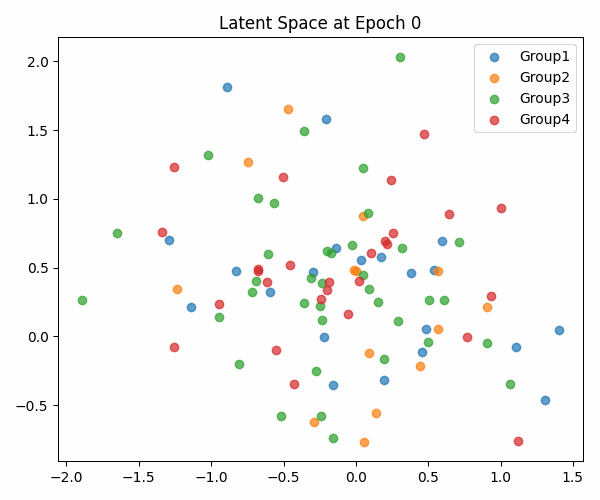

In [7]:
!pip install -q imageio

from IPython.display import Image, display
import imageio
import os

frame_dir = "frames"
frame_files = sorted([
    os.path.join(frame_dir, f)
    for f in os.listdir(frame_dir)
    if f.endswith(".png")
])

images = [imageio.imread(f) for f in frame_files]

imageio.mimsave("latent_training.gif", images, duration= 2)

print("GIF saved as latent_training.gif")

display(Image(filename="latent_training.gif"))